In [1]:
import pandas as pd

in_file = "/mnt/sunxh/Datasets_RNA/Yeast/predict.YeastSK.NNANN..m6a.tsv"
out_all_sites = "/mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.15s_site_level.tsv"
out_modified_sites = "/mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.15s_modified_sites.tsv"

PROB_TH = 0.9
COV_TH = 5
METHRATE_TH = 0.1

df = pd.read_csv(
    in_file,
    sep="\t",
    header=None,
    names=["contig", "position", "motif", "read_id", "label", "prob"]
)

df = df[df["contig"] == "15s"].copy()

df["prob"] = df["prob"].astype(float)

df["is_mod_read"] = (df["prob"] >= PROB_TH).astype(int)

group_cols = ["contig", "position"]

site_df = (
    df.groupby(group_cols, as_index=False)
      .agg(
          motif=("motif", "first"),
          coverage=("read_id", "nunique"),
          mod_reads=("is_mod_read", "sum"),
          mean_prob=("prob", "mean")
      )
)

site_df["meth_rate"] = site_df["mod_reads"] / site_df["coverage"].replace(0, pd.NA)

site_df["is_modified_site"] = (
    (site_df["coverage"] >= COV_TH) &
    (site_df["meth_rate"] > METHRATE_TH)
)

site_df.to_csv(out_all_sites, sep="\t", index=False)

mod_sites = site_df[site_df["is_modified_site"]].copy()
mod_sites.to_csv(out_modified_sites, sep="\t", index=False)

print("全部15s位点级结果已写入:", out_all_sites)
print("通过阈值筛选后的修饰位点已写入:", out_modified_sites)


全部15s位点级结果已写入: /mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.15s_site_level.tsv
通过阈值筛选后的修饰位点已写入: /mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.15s_modified_sites.tsv


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, chi2_contingency


out_file = "/mnt/sunxh/Datasets_RNA/Yeast/15s.out"

def read_seq_and_mea_dot(out_path):
    seq = None
    db_mea = None
    with open(out_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                continue
            if re.fullmatch(r"[ACGTUacgtu]+", line):
                seq = line.upper()
                continue
            if ("(" in line or "." in line) and "MEA=" in line:
                db_mea = line.split()[0]

    if seq is None or db_mea is None:
        raise ValueError("15s.out 中没有解析到序列或 MEA 结构")
    if len(seq) != len(db_mea):
        raise ValueError(f"序列长度 {len(seq)} 与结构长度 {len(db_mea)} 不一致")

    return seq, db_mea

seq_15s, db_15s = read_seq_and_mea_dot(out_file)
n = len(seq_15s)
print("15s 长度:", n)




15s 长度: 1649


In [3]:
dp_file = "/mnt/sunxh/Datasets_RNA/Yeast/15s_dp.ps"

def parse_bpp(dot_ps_path, n):
    P = np.zeros((n, n), dtype=float)
    with open(dot_ps_path) as f:
        for line in f:
            if "ubox" not in line:
                continue
            line = line.strip()
            if not line or line.startswith("%"):
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            try:
                i = int(parts[0])
                j = int(parts[1])
                v = float(parts[2])
            except ValueError:
                continue
            p = v * v
            if 1 <= i <= n and 1 <= j <= n:
                P[i-1, j-1] = p
                P[j-1, i-1] = p
    return P

P = parse_bpp(dp_file, n)

In [4]:

def positional_entropy(P):
    n = P.shape[0]
    S = np.zeros(n, dtype=float)
    for i in range(n):
        probs = P[i, :]
        pair_probs = probs[probs > 0]
        p_paired = float(pair_probs.sum())
        q = max(0.0, 1.0 - p_paired)
        if q > 0:
            all_probs = np.concatenate([pair_probs, [q]])
        else:
            all_probs = pair_probs
        S[i] = -np.sum(all_probs * np.log(all_probs))
    return S

S = positional_entropy(P)
pair_prob = P.sum(axis=1)
unpaired_prob = 1.0 - pair_prob

struct_type = ["stem" if c in "()" else "loop" for c in db_15s]

df_struct = pd.DataFrame({
    "position": np.arange(1, n + 1),          # 1-based
    "base": list(seq_15s),
    "struct_type": struct_type,
    "pair_prob": pair_prob,
    "unpaired_prob": unpaired_prob,
    "positional_entropy": S,
})

PAIR_TH = 0.7
UNP_TH = 0.7
ENT_TH = 1.0

high_conf_stem = (
    (df_struct["struct_type"] == "stem") &
    (df_struct["pair_prob"] >= PAIR_TH) &
    (df_struct["positional_entropy"] <= ENT_TH)
)
high_conf_loop = (
    (df_struct["struct_type"] == "loop") &
    (df_struct["unpaired_prob"] >= UNP_TH) &
    (df_struct["positional_entropy"] <= ENT_TH)
)

df_struct["high_conf"] = high_conf_stem | high_conf_loop

out_struct = "/mnt/sunxh/Datasets_RNA/Yeast/15s_structure_features.tsv"
df_struct.to_csv(out_struct, sep="\t", index=False)
print("结构特征写入:", out_struct)


结构特征写入: /mnt/sunxh/Datasets_RNA/Yeast/15s_structure_features.tsv


In [5]:
site_df_15s = site_df[site_df["contig"] == "15s"].copy()

merged_all = pd.merge(site_df_15s, df_struct, on="position", how="inner")
merged_all_path = "/mnt/sunxh/Datasets_RNA/Yeast/15s_site_struct_all.tsv"
merged_all.to_csv(merged_all_path, sep="\t", index=False)
print("位点级 + 结构特征写入:", merged_all_path)

merged_all = merged_all[merged_all["high_conf"]].copy()

merged_A = merged_all[merged_all["base"] == "A"].copy()

tab = pd.crosstab(merged_A["is_modified_site"], merged_A["struct_type"])
print("2×2 计数表：")
print(tab)

prop_pos = tab.loc[True]  / tab.loc[True].sum()
prop_bg  = tab.loc[False] / tab.loc[False].sum()
print("m6A 阳性位点结构分布：")
print(prop_pos)
print("背景位点结构分布：")
print(prop_bg)

位点级 + 结构特征写入: /mnt/sunxh/Datasets_RNA/Yeast/15s_site_struct_all.tsv
2×2 计数表：
struct_type       loop  stem
is_modified_site            
False              140   132
True                62    48
m6A 阳性位点结构分布：
struct_type
loop    0.563636
stem    0.436364
Name: True, dtype: float64
背景位点结构分布：
struct_type
loop    0.514706
stem    0.485294
dtype: float64


In [6]:
import pandas as pd

in_file = "/mnt/sunxh/Datasets_RNA/Yeast/predict.YeastSK.NNANN..m6a.tsv"

out_all_sites = "/mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.4rRNA_site_level.tsv"
out_modified_sites = "/mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.4rRNA_modified_sites.tsv"

PROB_TH = 0.9
COV_TH = 5
METHRATE_TH = 0.2

TARGET_CONTIGS = ["15s", "18s", "21s", "25s"]

df = pd.read_csv(
    in_file,
    sep="\t",
    header=None,
    names=["contig", "position", "motif", "read_id", "label", "prob"]
)

df = df[df["contig"].isin(TARGET_CONTIGS)].copy()

df["prob"] = df["prob"].astype(float)

df["is_mod_read"] = (df["prob"] >= PROB_TH).astype(int)

group_cols = ["contig", "position"]

site_df = (
    df.groupby(group_cols, as_index=False)
      .agg(
          motif=("motif", "first"),
          coverage=("read_id", "nunique"),
          mod_reads=("is_mod_read", "sum"),
          mean_prob=("prob", "mean")
      )
)

site_df["meth_rate"] = site_df["mod_reads"] / site_df["coverage"].replace(0, pd.NA)

site_df["is_modified_site"] = (
    (site_df["coverage"] >= COV_TH) &
    (site_df["meth_rate"] > METHRATE_TH)
)

site_df.to_csv(out_all_sites, sep="\t", index=False)

mod_sites = site_df[site_df["is_modified_site"]].copy()
mod_sites.to_csv(out_modified_sites, sep="\t", index=False)

print("4 条 rRNA 的位点级结果已写入:", out_all_sites)
print("通过阈值筛选后的修饰位点已写入:", out_modified_sites)


4 条 rRNA 的位点级结果已写入: /mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.4rRNA_site_level.tsv
通过阈值筛选后的修饰位点已写入: /mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.4rRNA_modified_sites.tsv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from scipy.stats import kruskal

site_file = "/mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.4rRNA_site_level.tsv"

df_all = pd.read_csv(site_file, sep="\t")

target_contigs = ["15s", "18s", "21s", "25s"]
colors = {
    "15s": (118/255, 113/255, 180/255),
    "18s": (31/255, 159/255, 120/255),
    "21s": (232/255, 30/255, 141/255),
    "25s": (218/255, 98/255, 33/255),
}

df_all = df_all[(df_all["contig"].isin(target_contigs)) & (df_all["coverage"] >= 10)].copy()
n_bins = 5
bins = np.linspace(0.0, 1.0, n_bins + 1)
labels = [f"{int(bins[i]*100)}–{int(bins[i+1]*100)}%" for i in range(n_bins)]

df_all["pos_norm"] = df_all.groupby("contig")["position"].transform(lambda x: x / x.max())
df_all["pos_bin"] = pd.cut(df_all["pos_norm"], bins=bins, labels=labels, include_lowest=True)

kw_results = {}
for contig in target_contigs:
    vals_list = []
    for lb in labels:
        vals = df_all.loc[
            (df_all["contig"] == contig) &
            (df_all["pos_bin"] == lb),
            "meth_rate"
        ].values
        if len(vals) >= 3:
            vals_list.append(vals)
    if len(vals_list) >= 2:
        _, p = kruskal(*vals_list)
        kw_results[contig] = p

y_low = df_all["meth_rate"].quantile(0.01)
y_high = df_all["meth_rate"].quantile(0.99)
y_low = max(0.0, y_low - 0.02)
y_high = min(1.0, y_high + 0.02)

base_pos = np.arange(1, n_bins + 1)
offset = 0.12



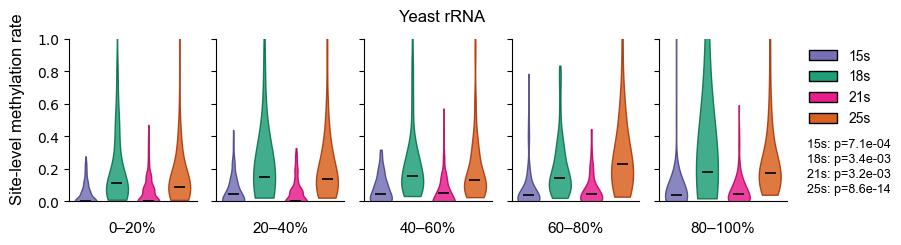

In [8]:
from matplotlib.patches import Patch
import matplotlib
fig, axes = plt.subplots(1, n_bins, figsize=(9, 3), sharey=True)
fig.subplots_adjust(wspace=0.1)
matplotlib.rcParams["font.family"] = "Arial"

for j, lb in enumerate(labels):
    ax = axes[j]
    data = []
    cols = []
    contigs_in_bin = []

    for contig in target_contigs:
        vals = df_all.loc[
            (df_all["contig"] == contig) &
            (df_all["pos_bin"] == lb),
            "meth_rate"
        ].values
        if len(vals) == 0:
            continue
        q1 = np.quantile(vals, 0.01)
        q99 = np.quantile(vals, 0.99)
        vals_f = vals[(vals >= q1) & (vals <= q99)]
        if len(vals_f) == 0:
            continue

        data.append(vals_f)
        cols.append(colors[contig])
        contigs_in_bin.append(contig)

    if not data:
        ax.set_xticks([])
        ax.set_title(lb)
        ax.set_ylim(y_low, y_high)
        continue

    positions = np.arange(1, len(data) + 1)

    parts = ax.violinplot(
        data,
        positions=positions,
        widths=0.7,
        showmeans=False,
        showmedians=True,
        showextrema=False,
        vert=True,
    )

    for body, col in zip(parts["bodies"], cols):
        edge_col = tuple(max(c - 0.2, 0) for c in col)
        body.set_facecolor(col)
        body.set_edgecolor(edge_col)
        body.set_alpha(0.85)

    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.2)

    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_ylim(y_low, y_high)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.text(
        0.5, -0.12, lb,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=11,
    )

x_text = 0.999
y_text = 0.4
for contig in target_contigs:
    if contig in kw_results:
        p = kw_results[contig]
        fig.text(
            x_text,
            y_text,
            f"{contig}: p={p:.1e}",
            transform=fig.transFigure,
            ha="right",
            va="top",
            fontsize=9,
        )
        y_text -= 0.05

handles = [Patch(facecolor=colors[c], edgecolor="black", label=c) for c in target_contigs]
fig.legend(
    handles=handles,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.74),
    frameon=False
)
fig.supylabel("Site-level methylation rate")
# fig.supxlabel("Yeast rRNA")
fig.suptitle("Yeast rRNA",y=0.83)
plt.tight_layout(rect=[0, 0, 0.9, 0.9])
out_pdf = "/mnt/sunxh/sunxh/wattmamba/new_result/supfig9A_YeastrRNA_quintiles.pdf"
plt.savefig(out_pdf, format="pdf", dpi=1200, bbox_inches="tight")
plt.show()


In [9]:
import re
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact, chi2_contingency

site_file = "/mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.4rRNA_site_level.tsv"
site_df_all = pd.read_csv(site_file, sep="\t")

def read_seq_and_mea_dot(out_path):
    seq = None
    db_mea = None
    with open(out_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                continue
            if re.fullmatch(r"[ACGTUacgtu]+", line):
                seq = line.upper()
                continue
            if ("(" in line or "." in line) and "MEA=" in line:
                db_mea = line.split()[0]
    if seq is None or db_mea is None:
        raise ValueError(f"{out_path} missing sequence or MEA structure")
    if len(seq) != len(db_mea):
        raise ValueError(f"{out_path}: seq length {len(seq)} != struct length {len(db_mea)}")
    return seq, db_mea

def parse_bpp(dot_ps_path, n):
    P = np.zeros((n, n), dtype=float)
    with open(dot_ps_path) as f:
        for line in f:
            if "ubox" not in line:
                continue
            line = line.strip()
            if not line or line.startswith("%"):
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            try:
                i = int(parts[0])
                j = int(parts[1])
                v = float(parts[2])
            except ValueError:
                continue
            p = v * v
            if 1 <= i <= n and 1 <= j <= n:
                P[i - 1, j - 1] = p
                P[j - 1, i - 1] = p
    return P

def positional_entropy(P):
    n = P.shape[0]
    S = np.zeros(n, dtype=float)
    for i in range(n):
        probs = P[i, :]
        pair_probs = probs[probs > 0]
        p_paired = float(pair_probs.sum())
        q = max(0.0, 1.0 - p_paired)
        if q > 0:
            all_probs = np.concatenate([pair_probs, [q]])
        else:
            all_probs = pair_probs
        S[i] = -np.sum(all_probs * np.log(all_probs))
    return S

PAIR_TH = 0.5
UNP_TH = 0.5
ENT_TH = 1.0

contigs = ["15s", "18s", "21s", "25s"]
base_dir = "/mnt/sunxh/Datasets_RNA/Yeast"

for contig in contigs:
    out_file = f"{base_dir}/{contig}.out"
    dp_file = f"{base_dir}/{contig}_dp.ps"

    seq, db = read_seq_and_mea_dot(out_file)
    n = len(seq)
    print(f"{contig} length:", n)

    P = parse_bpp(dp_file, n)
    S = positional_entropy(P)
    pair_prob = P.sum(axis=1)
    unpaired_prob = 1.0 - pair_prob
    struct_type = ["stem" if c in "()" else "loop" for c in db]

    df_struct = pd.DataFrame({
        "position": np.arange(1, n + 1),
        "base": list(seq),
        "struct_type": struct_type,
        "pair_prob": pair_prob,
        "unpaired_prob": unpaired_prob,
        "positional_entropy": S,
    })

    high_conf_stem = (
        (df_struct["struct_type"] == "stem") &
        (df_struct["pair_prob"] >= PAIR_TH) &
        (df_struct["positional_entropy"] <= ENT_TH)
    )
    high_conf_loop = (
        (df_struct["struct_type"] == "loop") &
        (df_struct["unpaired_prob"] >= UNP_TH) &
        (df_struct["positional_entropy"] <= ENT_TH)
    )
    df_struct["high_conf"] = high_conf_stem | high_conf_loop

    out_struct = f"{base_dir}/{contig}_structure_features.tsv"
    df_struct.to_csv(out_struct, sep="\t", index=False)
    print("structure features written:", out_struct)

    site_df = site_df_all[site_df_all["contig"] == contig].copy()
    merged_all = pd.merge(site_df, df_struct, on="position", how="inner")
    merged_all_path = f"{base_dir}/{contig}_site_struct_all.tsv"
    merged_all.to_csv(merged_all_path, sep="\t", index=False)
    print("site + structure written:", merged_all_path)

    merged_conf = merged_all[merged_all["high_conf"]].copy()
    merged_A = merged_conf[merged_conf["base"] == "A"].copy()
    if merged_A.empty:
        print(f"{contig}: no high-confidence A sites, skip enrichment.")
        continue

    tab = pd.crosstab(merged_A["is_modified_site"], merged_A["struct_type"])
    print(f"{contig} 2x2 table:")
    print(tab)

    if True in tab.index and False in tab.index and "stem" in tab.columns and "loop" in tab.columns:
        prop_pos = tab.loc[True] / tab.loc[True].sum()
        prop_bg = tab.loc[False] / tab.loc[False].sum()
        print(f"{contig} m6A-positive structure distribution:")
        print(prop_pos)
        print(f"{contig} background structure distribution:")
        print(prop_bg)

        if tab.shape == (2, 2):
            oddsratio, p_fisher = fisher_exact(tab.values)
            print(f"{contig} Fisher exact p =", p_fisher)
        else:
            chi2, p_chi, dof, _ = chi2_contingency(tab.values)
            print(f"{contig} Chi-square p =", p_chi)
    else:
        print(f"{contig}: contingency table not 2x2, skip Fisher/Chi-square.")


15s length: 1649
structure features written: /mnt/sunxh/Datasets_RNA/Yeast/15s_structure_features.tsv
site + structure written: /mnt/sunxh/Datasets_RNA/Yeast/15s_site_struct_all.tsv
15s 2x2 table:
struct_type       loop  stem
is_modified_site            
False              191   183
True                30    18
15s m6A-positive structure distribution:
struct_type
loop    0.625
stem    0.375
Name: True, dtype: float64
15s background structure distribution:
struct_type
loop    0.510695
stem    0.489305
dtype: float64
15s Fisher exact p = 0.16704201717298595
18s length: 1800
structure features written: /mnt/sunxh/Datasets_RNA/Yeast/18s_structure_features.tsv
site + structure written: /mnt/sunxh/Datasets_RNA/Yeast/18s_site_struct_all.tsv
18s 2x2 table:
struct_type       loop  stem
is_modified_site            
False              146    90
True                78    61
18s m6A-positive structure distribution:
struct_type
loop    0.561151
stem    0.438849
Name: True, dtype: float64
18s backgro

15s Binomial test p : 0.2687598253244401
18s Binomial test p : 0.002472712634119462
21s Binomial test p : 0.0735778916416825
25s Binomial test p : 0.0005640313500999495


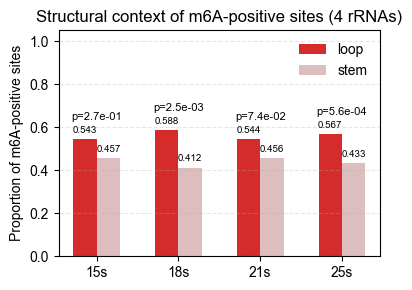

summary written to /mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.4rRNA_loop_vs_stem_enrichment.tsv


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, chi2_contingency
from scipy.stats import binomtest

site_file = "/mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.4rRNA_site_level.tsv"
base_struct_dir = "/mnt/sunxh/Datasets_RNA/Yeast"

site_df_all = pd.read_csv(site_file, sep="\t")

contigs = ["15s", "18s", "21s", "25s"]
coverage_th = 10
METH_TH = 0.05

color_loop = (214/255, 43/255, 43/255)
color_stem = (221/255, 189/255, 189/255)


summary_rows = []

loop_props = []
stem_props = []
loop_counts = []
stem_counts = []
contigs_used = []
fisher_ps = []
matplotlib.rcParams["font.family"] = "Arial"

for contig in contigs:
    struct_file = f"{base_struct_dir}/{contig}_structure_features.tsv"
    struct_df = pd.read_csv(struct_file, sep="\t")

    site_df = site_df_all[(site_df_all["contig"] == contig) &
                          (site_df_all["coverage"] >= coverage_th)].copy()
    if site_df.empty:
        continue

    df = pd.merge(site_df, struct_df, on="position", how="inner")
    df = df[df["base"] == "A"].copy()
    if "high_conf" in df.columns:
        df = df[df["high_conf"]].copy()
    if df.empty:
        continue

    df["is_m6A_site"] = df["meth_rate"] >= METH_TH
    df["struct_simple"] = np.where(df["struct_type"] == "stem", "stem", "loop")

    tab = pd.crosstab(df["is_m6A_site"], df["struct_simple"])
    if not ({True, False} <= set(tab.index)) or not ({"stem", "loop"} <= set(tab.columns)):
        print(f"{contig}: contingency table incomplete, skipped")
        continue

    n_loop = int(tab.loc[True, "loop"])
    n_stem = int(tab.loc[True, "stem"])
    n_total = n_loop + n_stem
    if n_total > 0:
        res = binomtest(n_loop, n_total, p=0.5, alternative="two-sided")
        p_binom = res.pvalue
    else:
        p_binom = np.nan
    fisher_ps.append(p_binom)
    print(f"{contig} Binomial test p :", p_binom)



    prop_pos = tab.loc[True] / tab.loc[True].sum()
    prop_bg  = tab.loc[False] / tab.loc[False].sum()

    for struct in ["loop", "stem"]:
        summary_rows.append({
            "contig": contig,
            "struct": struct,
            "class": "m6A_positive",
            "count": int(tab.loc[True, struct]),
            "proportion": float(prop_pos[struct]),
        })
        summary_rows.append({
            "contig": contig,
            "struct": struct,
            "class": "background",
            "count": int(tab.loc[False, struct]),
            "proportion": float(prop_bg[struct]),
        })

    loop_props.append(float(prop_pos["loop"]))
    stem_props.append(float(prop_pos["stem"]))
    loop_counts.append(int(tab.loc[True, "loop"]))
    stem_counts.append(int(tab.loc[True, "stem"]))
    contigs_used.append(contig)

if contigs_used:
    x = np.arange(len(contigs_used))*0.7
    width = 0.2

    fig, ax = plt.subplots(figsize=(4, 3))

    bars_loop = ax.bar(x - width/2, loop_props, width, label="loop", color=color_loop)
    bars_stem = ax.bar(x + width/2, stem_props, width, label="stem", color=color_stem)
    max_prop = max(loop_props + stem_props) if loop_props else 0
    ax.set_ylim(0, max(1.05, max_prop + 0.15))

    ax.set_xticks(x)
    ax.set_xticklabels(contigs_used)
    ax.set_ylabel("Proportion of m6A-positive sites")
    ax.set_title("Structural context of m6A-positive sites (4 rRNAs)")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    for i, bar in enumerate(bars_loop):
        h = bar.get_height()
        c = loop_counts[i]
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f"{h:.3f}",
                ha="center", va="bottom", fontsize=7)

    for i, bar in enumerate(bars_stem):
        h = bar.get_height()
        c = stem_counts[i]
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f"{h:.3f}",
                ha="center", va="bottom", fontsize=7)
    for i, name in enumerate(contigs_used):
        p = fisher_ps[i]
        if np.isfinite(p):
            ax.text(x[i], max(loop_props[i], stem_props[i]) + 0.08,
                    f"p={p:.1e}",
                    ha="center", va="bottom", fontsize=8)

    ax.legend(frameon=False)
    plt.tight_layout()
    out_pdf = "/mnt/sunxh/sunxh/wattmamba/new_result/supfig9B_YeastrRNA_loop_stem.pdf"
    plt.savefig(out_pdf, format="pdf", dpi=1200, bbox_inches="tight")
    plt.show()

summary_df = pd.DataFrame(summary_rows)
summary_out = "/mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.4rRNA_loop_vs_stem_enrichment.tsv"
summary_df.to_csv(summary_out, sep="\t", index=False)
print("summary written to", summary_out)



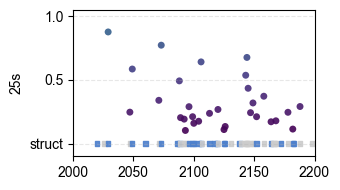

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

site_file = "/mnt/sunxh/sunxh/wattmamba/new_result/YeastSK.4rRNA_site_level.tsv"
base_struct_dir = "/mnt/sunxh/Datasets_RNA/Yeast"

site_df_all = pd.read_csv(site_file, sep="\t")

contig = "25s"
coverage_th = 10
METH_TH = 0.1
matplotlib.rcParams["font.family"] = "Arial"

region_start = 2000
region_end   = 2200

color_loop = (0.8, 0.8, 0.8)
color_stem = (0.3, 0.5, 0.8)

struct_file = f"{base_struct_dir}/{contig}_structure_features.tsv"
struct_df = pd.read_csv(struct_file, sep="\t")

site_df = site_df_all[(site_df_all["contig"] == contig) &
                      (site_df_all["coverage"] >= coverage_th)].copy()

df = pd.merge(site_df, struct_df, on="position", how="inner")
df = df[df["base"] == "A"].copy()
if "high_conf" in df.columns:
    df = df[df["high_conf"]].copy()

df = df[(df["position"] >= region_start) & (df["position"] <= region_end)].copy()

df["struct_simple"] = np.where(df["struct_type"] == "stem", "stem", "loop")
df_pos = df[df["meth_rate"] >= METH_TH].copy()

fig, ax = plt.subplots(figsize=(3.5, 2))

pos = df["position"].values
y_struct = np.zeros_like(pos, dtype=float)

colors_struct = np.array([
    color_stem if s == "stem" else color_loop
    for s in df["struct_simple"].values
])

ax.scatter(pos, y_struct, c=colors_struct, s=10, marker="s", alpha=0.9)

if not df_pos.empty:
    sc = ax.scatter(
        df_pos["position"].values,
        df_pos["meth_rate"].values,
        c=df_pos["meth_rate"].values,
        cmap="viridis",
        s=25,
        alpha=0.9,
        edgecolors="none"
    )

ax.set_xlim(region_start, region_end)
ax.set_ylim(-0.1, 1.05)
ax.set_ylabel(contig)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["struct", "0.5", "1.0"])
ax.set_xlabel("")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
out_pdf = "/mnt/sunxh/sunxh/wattmamba/new_result/supfig9C_YeastrRNA_Position.pdf"
plt.savefig(out_pdf, format="pdf", dpi=1200, bbox_inches="tight")
plt.show()
